Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [98]:
real_deconv_combined.save_replication_deconvolution()

Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_combined.npy
Saved to: data/copy_correction//F_combined.npy


In [518]:
from src.GenomeDeconvolution import GenomeDeconvolution

genome_deconvolution = GenomeDeconvolution(save_dir=None)

todo: Copy correction is not in place


In [590]:
from src.RealDataReplication import read_n_fr_b

chrom = 16
deconv_span = 770500, 772000

N, fr, b = read_n_fr_b(chrom, deconv_span)
genome_deconvolution.load_chrom_span(chrom, deconv_span)


Loading chromosome reads: 16
Applying a normalization for length distribution
Loading chromosome reads: 16
Applying a normalization for length distribution
Adding a deconvolution offset to G: 1


In [591]:
genome_deconvolution.combined_model.deconvolve(N=N, f_replication=fr, b=b)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.1
Deconvolving bin size: 10x10
of G shape: (31, 3900)
Padding type: both
Deconvolving with gamma=0.1
0/3900 - 00:00:00.128
500/3900 - 00:00:57.978
1000/3900 - 00:01:55.826
1500/3900 - 00:02:50.325
2000/3900 - 00:03:47.596
2500/3900 - 00:04:47.688
3000/3900 - 00:05:58.484
3500/3900 - 00:06:59.742
Deconvolved in : 00:07:48.356
The fitting norm is 4.07, the smoothing norm is: 2.35


In [815]:
F = genome_deconvolution.combined_model.deconvolved_f_value
G = genome_deconvolution.combined_model.G

predicted_G = N@H@(F * fr.values.reshape((-1, 1)))*b
np.mean(np.sqrt((predicted_G/G - 1)**2))


0.18499424401100795

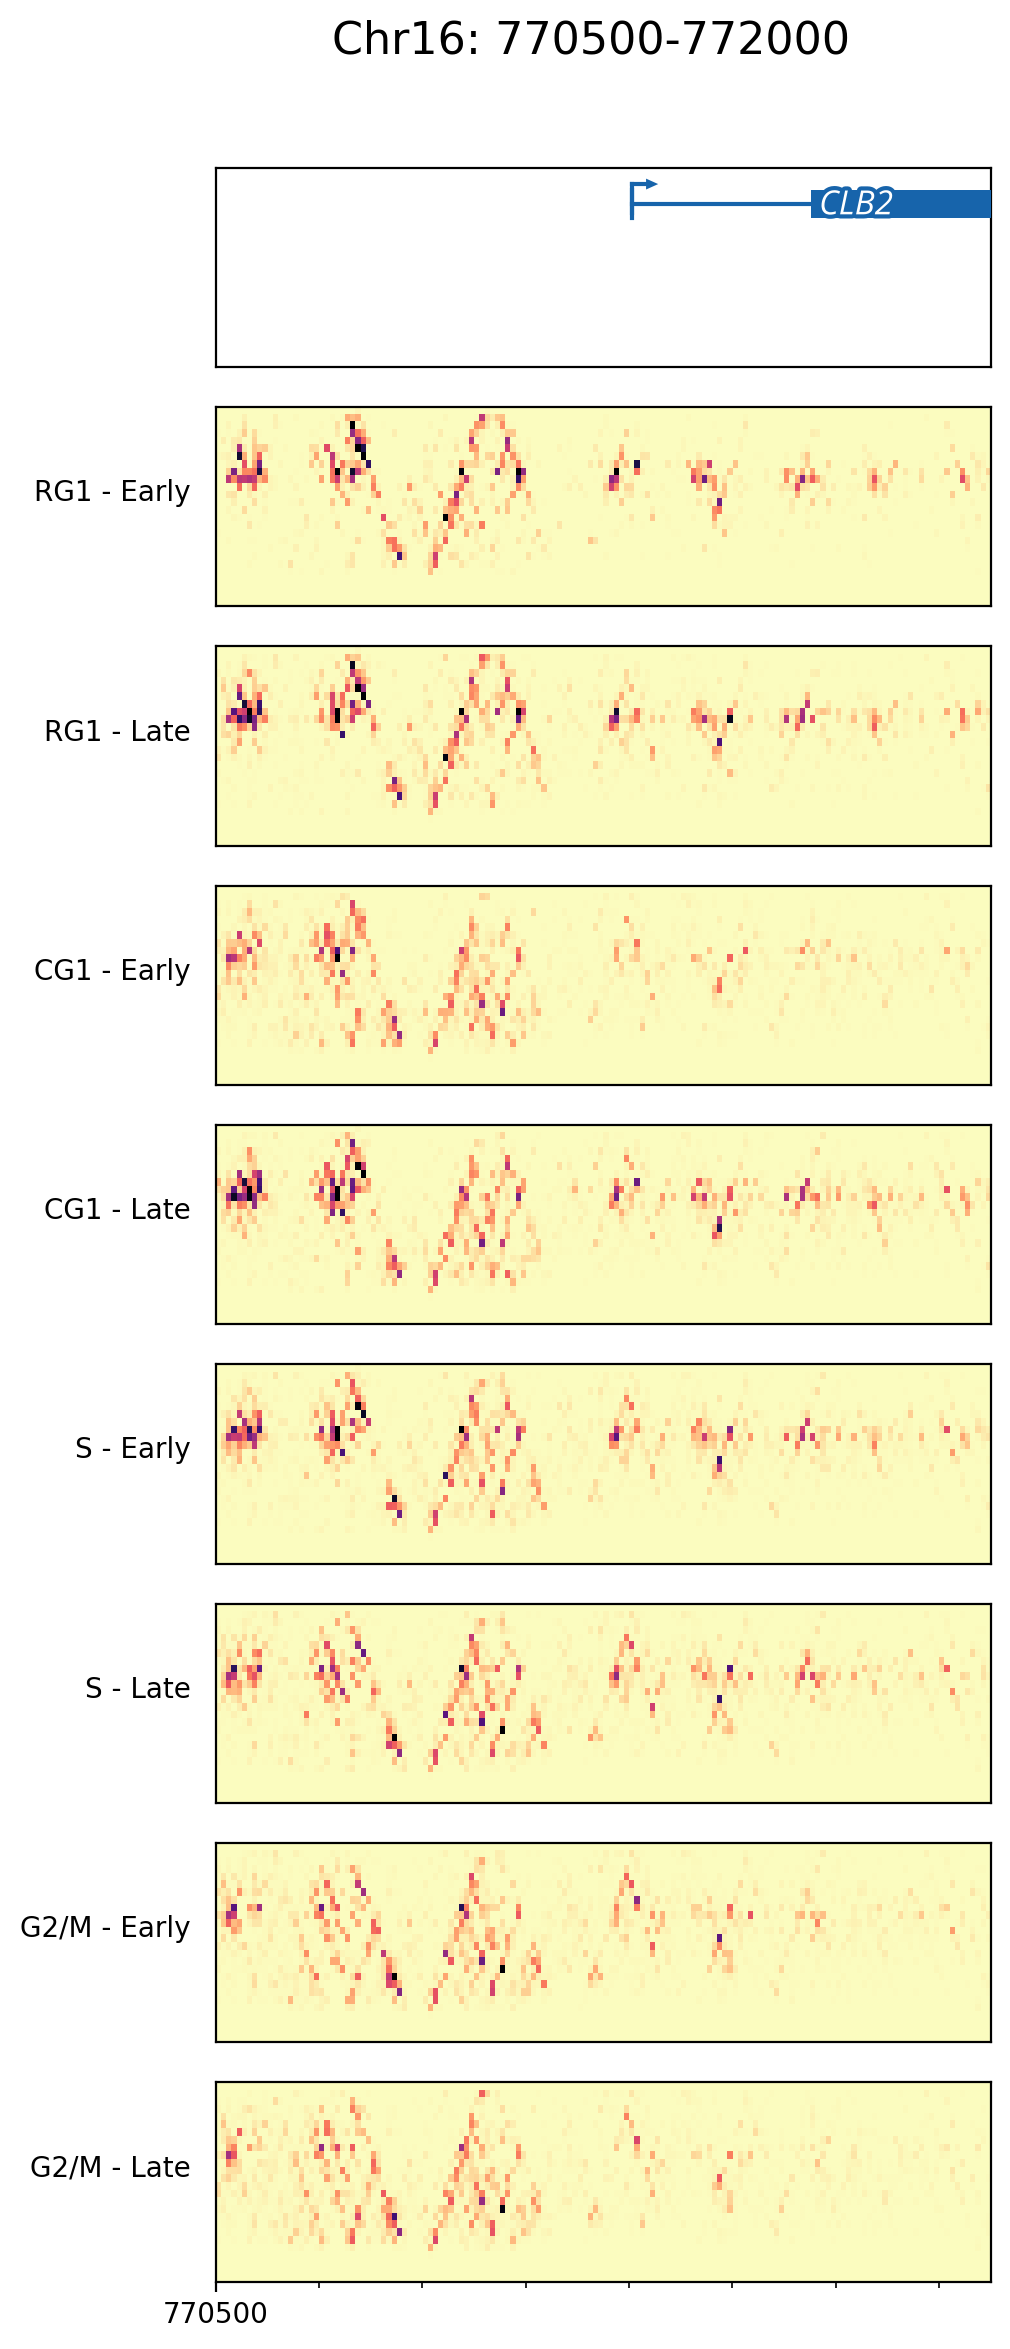

In [592]:
fig = genome_deconvolution.plot_deconvolved_result(figwidth=5, vmin=0.75, vmax=20)

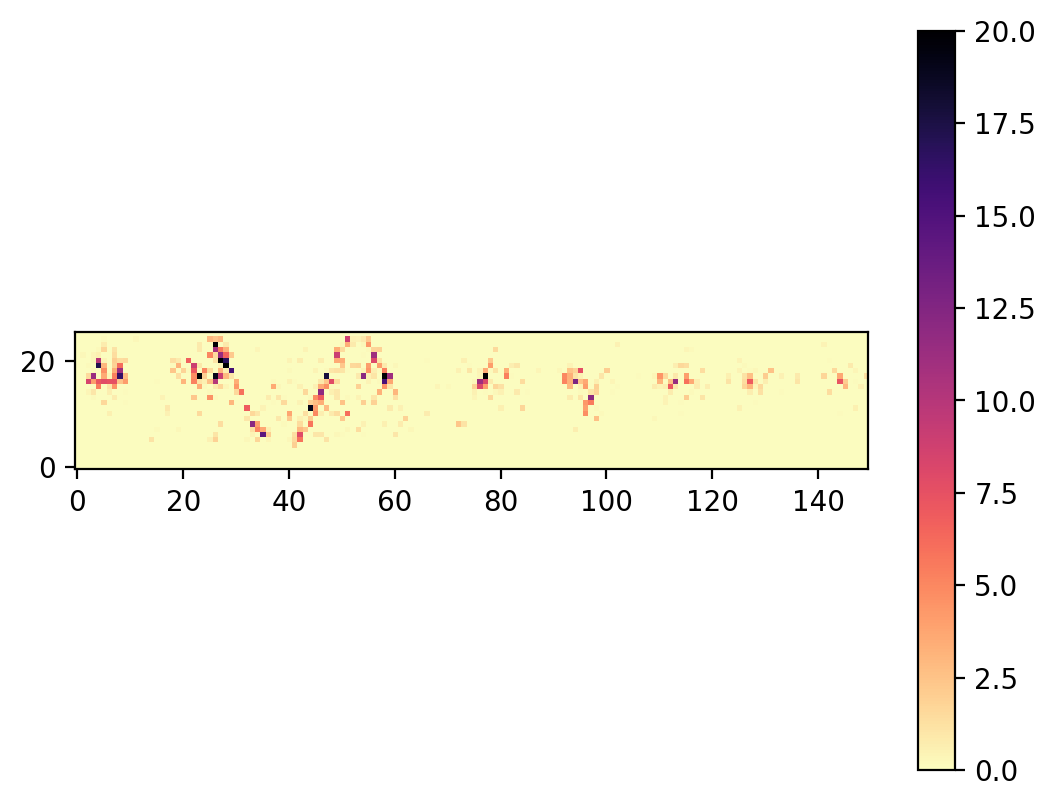

In [644]:
# Checking role of the offset on the deconvolution of G (+1)
# and its effect on F (remove the offset with -1). I notice
# values slightly lower than 1 in the final deconvolution...

n, m = H.shape
f_imgs = f.reshape((m, 26, -1))

plt.imshow(f_imgs[0], cmap='magma_r', origin='lower', vmin=0, vmax=20)
plt.colorbar()


In [647]:

debug_psuedocount = GenomeDeconvolution(save_dir=None)

from src.RealDataReplication import read_n_fr_b

chrom = 16
deconv_span = 770500, 772000

N, fr, b = read_n_fr_b(chrom, deconv_span)
debug_psuedocount.load_chrom_span(chrom, deconv_span)


Loading chromosome reads: 16
Applying a normalization for length distribution
Loading chromosome reads: 16
Applying a normalization for length distribution
Adding a deconvolution offset to G: 1


In [677]:
G = genome_deconvolution.combined_model.G

# Find a non-zero example, we are interested in examples in which
# the deconvolution works well with the +1 pseudocount but not without it
# then we can identify if a better pseudocount is appropriate, or adjust some other
# aspect of the model that is contributing to the poor fits with low/0 counts
selected_indices = (G.max(axis=0) > 30) & (G.min(axis=0) == 1)
selected_Gs = G[:, selected_indices]

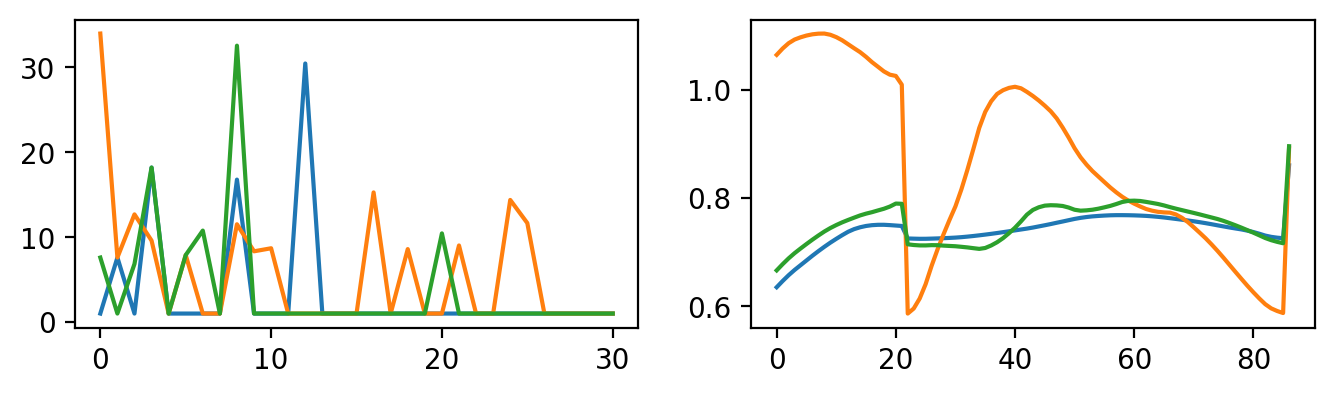

In [672]:
F = genome_deconvolution.combined_model.deconvolved_f_value

plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(selected_Gs)

plt.subplot(1, 2, 2)
plt.plot(F[:, selected_indices])

In [675]:
# What do the deconvolutions look like with different offsets?
# 1 is known to be good
# values close to 0 (1e-3, 1e-5) produce an artifact between the seam between the end of 
# CG1 and the start of S-phase.


In [856]:
# With a gamma of 0.1, and an offset of 0,
# how will the deconvolution results look? I suspect, it will
# remove a lot of the low-level noise values that would have came up with the offset.
# The question that remains 


# Now remove the offset
removed_offset_selected_Gs = G-1
debug_psuedocount.combined_model.G_deconvolution_offset = 1
debug_psuedocount.combined_model.gamma = 0.007
debug_psuedocount.combined_model.deconvolve(G=removed_offset_selected_Gs, 
    N=N, b=b, f_replication=fr)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.1
Deconvolving bin size: 10x10
of G shape: (31, 3900)
Padding type: both
Deconvolving with gamma=0.1
0/3900 - 00:00:00.116
500/3900 - 00:00:52.948
1000/3900 - 00:01:45.555
1500/3900 - 00:02:37.602
2000/3900 - 00:03:31.602
2500/3900 - 00:04:22.766
3000/3900 - 00:05:13.868
3500/3900 - 00:06:06.090
Deconvolved in : 00:06:47.521
The fitting norm is 4.07, the smoothing norm is: 2.35


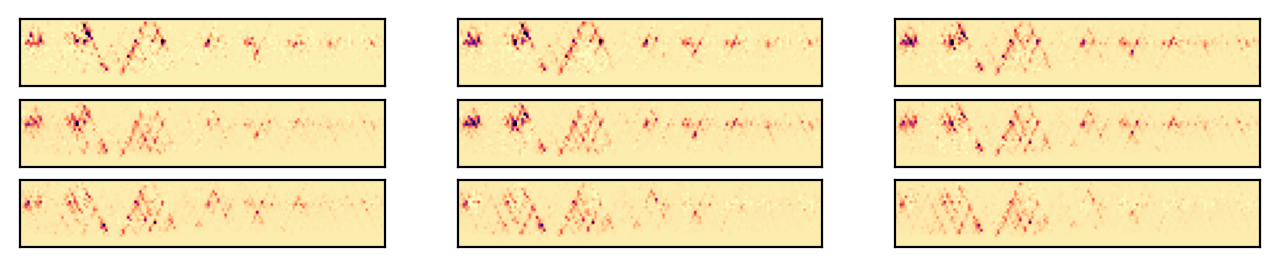

In [857]:
# Checking role of the offset on the deconvolution of G (+1)
# and its effect on F (remove the offset with -1). I notice
# values slightly lower than 1 in the final deconvolution...

n, m = H.shape
f_offset_0 = debug_psuedocount.combined_model.deconvolved_f_value
f_imgs = f_offset_0.reshape((m, 26, -1))

plt.figure(figsize=(8, 2))
for i, img_idx in enumerate(list(range(0, 87, 10))):
    plt.subplot(4, 3, i+1)
    plt.imshow(f_imgs[img_idx], cmap='magma_r', origin='lower', vmin=0, vmax=20,
              aspect='auto')
    plt.xticks([])
    plt.yticks([])


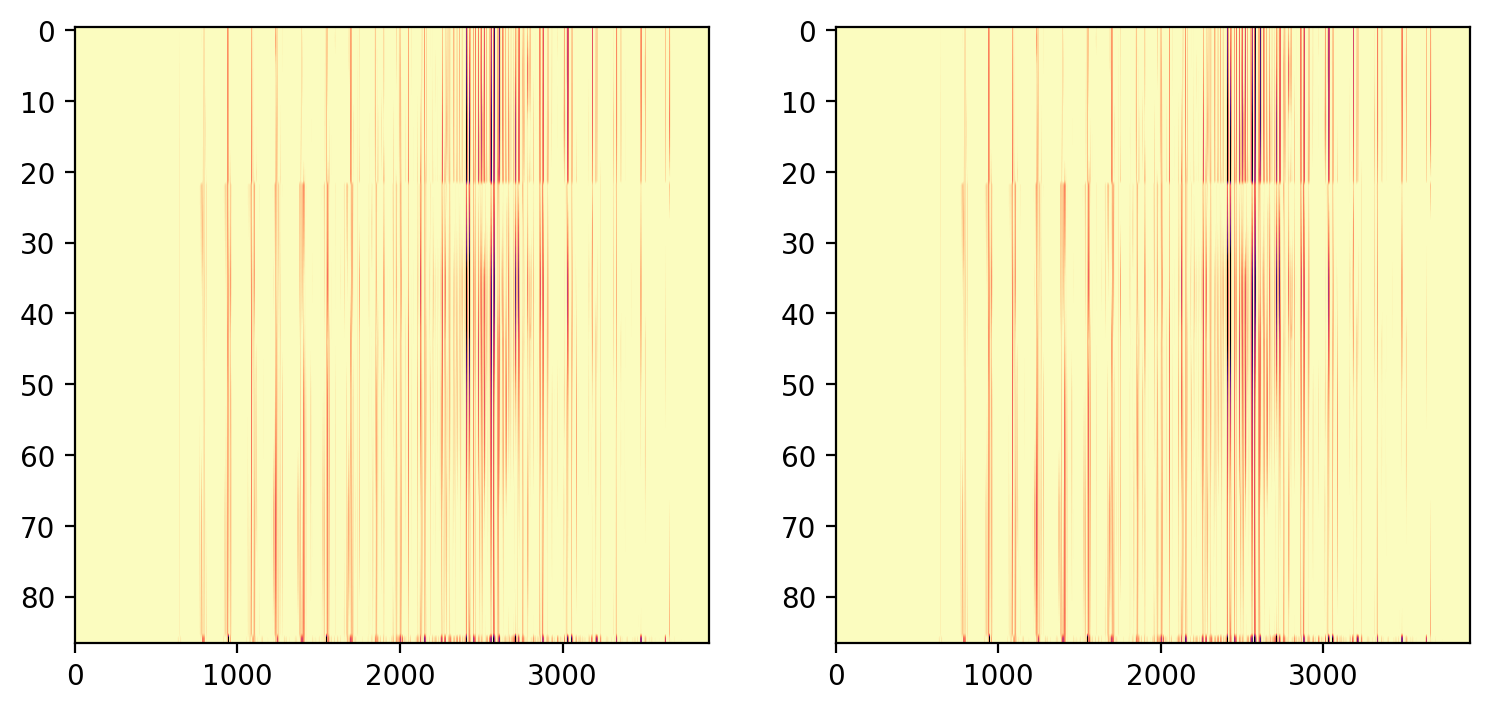

In [863]:
plt.figure(figsize=(9, 4))


plt.subplot(1, 2, 1)
plt.imshow(f, aspect='auto', cmap='magma_r', vmin=0, vmax=10)

plt.subplot(1, 2, 2)
plt.imshow(f_offset_0, aspect='auto', cmap='magma_r', vmin=1, vmax=10)

(0.0, 2.0)

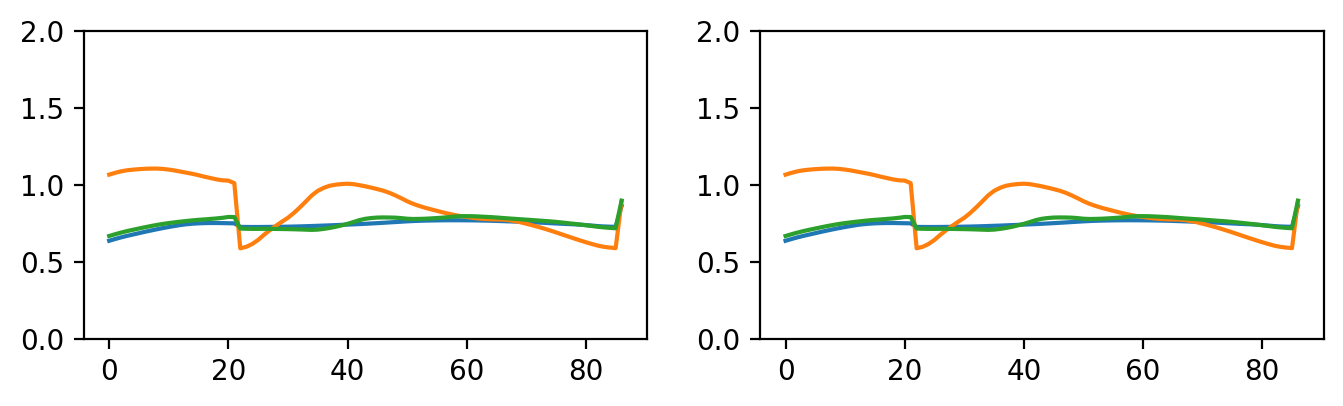

In [859]:
F = genome_deconvolution.combined_model.deconvolved_f_value

plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(F[:, selected_indices])
plt.ylim(0, 2)

plt.subplot(1, 2, 2)
plt.plot(f_offset_0[:, selected_indices])
plt.ylim(0, 2)

In [860]:
g_predicted = N@H@(f * fr.values.reshape((-1, 1)))*b

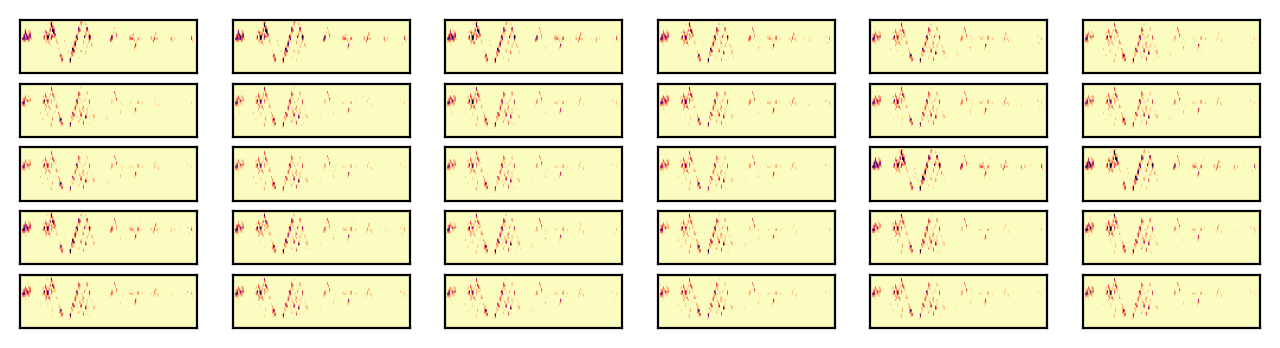

In [864]:
# Checking role of the offset on the deconvolution of G (+1)
# and its effect on F (remove the offset with -1). I notice
# values slightly lower than 1 in the final deconvolution...

plt.figure(figsize=(8, 2))
for i, img_idx in enumerate(list(range(30))):
    plt.subplot(5, 6, i+1)
    plt.imshow(g_predicted[img_idx].reshape((26, -1)), cmap='magma_r', origin='lower', vmin=1, vmax=20,
              aspect='auto')
    plt.xticks([])
    plt.yticks([])


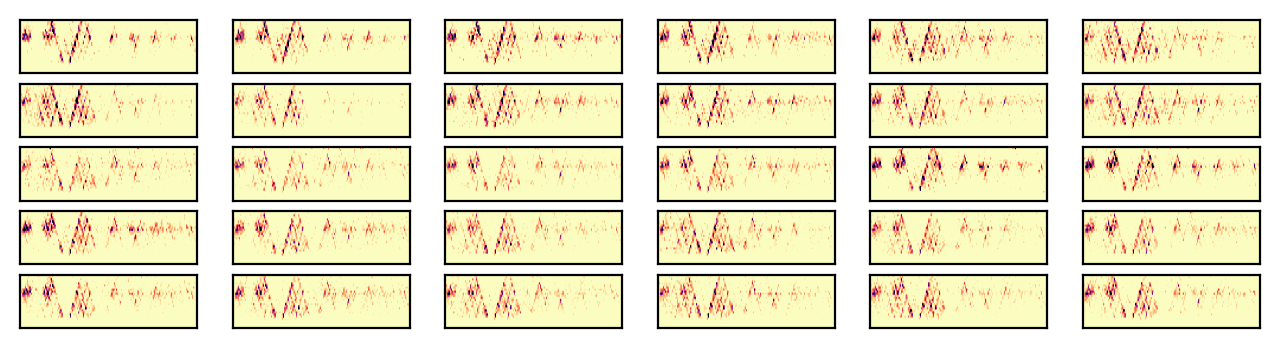

In [862]:

plt.figure(figsize=(8, 2))
for i, img_idx in enumerate(list(range(30))):
    plt.subplot(5, 6, i+1)
    plt.imshow(removed_offset_selected_Gs[img_idx].reshape((26, -1)), cmap='magma_r', origin='lower', 
               vmin=1, vmax=20,
              aspect='auto')
    plt.xticks([])
    plt.yticks([])
